## Required Assignment 2.2: Measures of Center and Spread
**Expected Time: 60 Minutes**


**Total Points: 20**

Measures of central tendency for datasets are typically mean, median, mode, variance, and standard deviation. We will explore the mode in later modules. This assignment focuses on using pandas to compute numerical summaries of data. You will load in a dataset and compute the mean, median, variance, and standard deviation of numeric features in the data. You will also examine the spread of the data using quartiles and the interquartile range, also identifying outliers using the  1.5×𝐼𝑄𝑅  rule.


## Index:

- [Problem 1](#Problem-1:-Load-the-Data)
- [Problem 2](#Problem-2:-Base-Salary-Distribution-Mean)
- [Problem 3](#Problem-3:-Base-Salary-Distribution-Median)
- [Problem 4](#Problem-4:-Determining-Quartiles)
- [Problem 5](#Problem-5:-Interquartile-Range)
- [Problem 6](#Problem-6:-Rule-for-Outliers)
- [Problem 7](#Problem-7:-Dropping-Outliers)
- [Problem 8](#Finding-the-Mean-with-no-Outliers)
- [Problem 9]()
- [Problem 10](#Standard-Deviation-with-`numpy`)
- [Problem 11](#Standard-Deviation-with-`pandas`)
- [Problem 12]()
- [Problem 13](#Measure-of-Center)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Sometimes, it is not enough to simply generate data and plots. Quite often, your job will be to take the data and make sense of it for someone else. In this try-it activity, you will use the provided Jupyter Notebook Links to an external site.and complete your calculations. Then, you will report your findings back to your peers as a discussion post. This structure will test your ability to generate the data in the Jupyter Notebook and your ability to communicate your findings meaningfully to others.

In this activity, you will be looking at baseball players’ salaries. Compare sample means for different sample sizes. Then, explain how the distribution of these sample means changes as the sample size changes and how the mean and standard deviation of the distributions change as well. Compose your explanation as an email to a fellow co-worker explaining to them what the sample size changes (and the subsequent changes in mean and standard deviation) mean for data analysis.

### The Data



The dataset for this assignment comes from New York City's Open Data and contains information about the citywide payroll data.  Below, you are to load the data from a `.csv` file.  

[Back to top](#Index:) 

### Problem 1:  Load the Data

**1 Point**

Below, load the data file located in the `data` folder named `nyc_salaries.csv`.  Assign your DataFrame to `nyc_salary_data`.

In [2]:
###GRADED

nyc_salary_data = ''

###BEGIN SOLUTION
nyc_salary_data = pd.read_csv('data/nyc_salaries.csv')
###END SOLUTION

### Examine the Data

Now that the data is loaded, information about the datatypes and missing values, as well as a quick look at the first five rows of the data, can be retrieved using the `.info()` and `.head()` methods.

In [3]:
nyc_salary_data.shape

(590210, 17)

In [4]:
nyc_salary_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 590210 entries, 0 to 590209
Data columns (total 17 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   fiscal_year                 590210 non-null  int64  
 1   payroll_number              590210 non-null  int64  
 2   agency_name                 590210 non-null  str    
 3   last_name                   589838 non-null  str    
 4   first_name                  589835 non-null  str    
 5   agency_start_date           590147 non-null  str    
 6   work_location_borough       590207 non-null  str    
 7   title_description           590204 non-null  str    
 8   leave_status_as_of_july_31  590210 non-null  str    
 9   base_salary                 590210 non-null  float64
 10  pay_basis                   590210 non-null  str    
 11  regular_hours               590210 non-null  float64
 12  regular_gross_paid          590210 non-null  float64
 13  ot_hours                 

In [5]:
nyc_salary_data.head()

,fiscal_year,payroll_number,agency_name,last_name,first_name,agency_start_date,work_location_borough,title_description,leave_status_as_of_july_31,base_salary,pay_basis,regular_hours,regular_gross_paid,ot_hours,total_ot_paid,total_other_pay,mid_init
0,2020,17,OFFICE OF EMERGENCY MANAGEMENT,BEREZIN,MIKHAIL,2015-08-10T00:00:00.000,BROOKLYN,EMERGENCY PREPAREDNESS MANAGER,ACTIVE,86005.0,per Annum,1820.0,84698.21,0.0,0.0,0.0,NaN
1,2020,17,OFFICE OF EMERGENCY MANAGEMENT,GEAGER,VERONICA,2016-09-12T00:00:00.000,BROOKLYN,EMERGENCY PREPAREDNESS MANAGER,ACTIVE,86005.0,per Annum,1820.0,84698.21,0.0,0.0,0.0,M
2,2020,17,OFFICE OF EMERGENCY MANAGEMENT,RAMANI,SHRADDHA,2016-02-22T00:00:00.000,BROOKLYN,EMERGENCY PREPAREDNESS MANAGER,ACTIVE,86005.0,per Annum,1820.0,84698.21,0.0,0.0,0.0,NaN
3,2020,17,OFFICE OF EMERGENCY MANAGEMENT,ROTTA,JONATHAN,2013-09-16T00:00:00.000,BROOKLYN,EMERGENCY PREPAREDNESS MANAGER,ACTIVE,86005.0,per Annum,1820.0,84698.21,0.0,0.0,0.0,D
4,2020,17,OFFICE OF EMERGENCY MANAGEMENT,WILSON II,ROBERT,2018-04-30T00:00:00.000,BROOKLYN,EMERGENCY PREPAREDNESS MANAGER,ACTIVE,86005.0,per Annum,1820.0,84698.21,0.0,0.0,0.0,P


In [6]:
nyc_salary_data.head()

,fiscal_year,payroll_number,agency_name,last_name,first_name,agency_start_date,work_location_borough,title_description,leave_status_as_of_july_31,base_salary,pay_basis,regular_hours,regular_gross_paid,ot_hours,total_ot_paid,total_other_pay,mid_init
0,2020,17,OFFICE OF EMERGENCY MANAGEMENT,BEREZIN,MIKHAIL,2015-08-10T00:00:00.000,BROOKLYN,EMERGENCY PREPAREDNESS MANAGER,ACTIVE,86005.0,per Annum,1820.0,84698.21,0.0,0.0,0.0,NaN
1,2020,17,OFFICE OF EMERGENCY MANAGEMENT,GEAGER,VERONICA,2016-09-12T00:00:00.000,BROOKLYN,EMERGENCY PREPAREDNESS MANAGER,ACTIVE,86005.0,per Annum,1820.0,84698.21,0.0,0.0,0.0,M
2,2020,17,OFFICE OF EMERGENCY MANAGEMENT,RAMANI,SHRADDHA,2016-02-22T00:00:00.000,BROOKLYN,EMERGENCY PREPAREDNESS MANAGER,ACTIVE,86005.0,per Annum,1820.0,84698.21,0.0,0.0,0.0,NaN
3,2020,17,OFFICE OF EMERGENCY MANAGEMENT,ROTTA,JONATHAN,2013-09-16T00:00:00.000,BROOKLYN,EMERGENCY PREPAREDNESS MANAGER,ACTIVE,86005.0,per Annum,1820.0,84698.21,0.0,0.0,0.0,D
4,2020,17,OFFICE OF EMERGENCY MANAGEMENT,WILSON II,ROBERT,2018-04-30T00:00:00.000,BROOKLYN,EMERGENCY PREPAREDNESS MANAGER,ACTIVE,86005.0,per Annum,1820.0,84698.21,0.0,0.0,0.0,P


[Back to top](#Index:) 

### Problem 2: Base Salary Distribution Mean

**1 Point**

Use pandas to determine the mean of the `base_salary` column.  Assign your answer to the variable `ans_2` below.

In [7]:
nyc_salary_data['base_salary'].head(40)

0      86005.0
1      86005.0
2      86005.0
3      86005.0
4      86005.0
5      86005.0
6      94415.0
7      86005.0
8      86005.0
9      67676.0
10    236088.0
11     86005.0
12     83791.0
13     83791.0
14     73403.0
15     62306.0
16     73049.0
17     66603.0
18     67677.0
19     68751.0
20     71231.0
21     73317.0
22     67980.0
23     73049.0
24     75197.0
25     59083.0
26     66603.0
27     66603.0
28     59740.0
29     73049.0
30     66950.0
31     62310.0
32     71000.0
33     60157.0
34     67677.0
35     73049.0
36     96717.0
37     66950.0
38     66603.0
39     62306.0
Name: base_salary, dtype: float64

In [8]:
###GRADED

ans_2 = ''

###BEGIN SOLUTION
ans_2 = nyc_salary_data['base_salary'].mean()
ans_2
###END SOLUTION

np.float64(46719.46439313126)

[Back to top](#Index:) 

### Problem 3: Base Salary Distribution Median


**1 Point**


Use the pandas `.median()` method to find the median of the `base_salary` column. Assign your answer to the variable `ans_3` below.

In [9]:
###GRADED

ans_3 = ''

###BEGIN SOLUTION
ans_3 = nyc_salary_data['base_salary'].median()
ans_3
###END SOLUTION

np.float64(44930.0)

In [10]:
nyc_salary_data['base_salary'].std()

np.float64(45027.0016932455)

[Back to top](#Index:) 

### Problem 4: Determining Quartiles

**2 Points**

The first quartile in our data is found by arranging the data from least to greatest and determining the median of the lower half of the data.  

The third quartile is the median of the upper half of the data.  

Pandas has a `.quantile()` method that accepts an argument as a single value or list of values of quantiles to compute.  

- Use the `.quantile()` method  with argument equal to `.25` to determine the first quartile of the `base_salary` column. Assign your answer to the variable `first_quartile`.
- Use the `.quantile()` method  with argument equal to `.75` to determine the third quartile of the `base_salary` column. Assign your answer to the variable `third_quartile`.



In [11]:
###GRADED

first_quartile = ''
third_quartile = ''

###BEGIN SOLUTION
first_quartile = nyc_salary_data['base_salary'].quantile(.25)
print(first_quartile)
third_quartile = nyc_salary_data['base_salary'].quantile(.75)
print(third_quartile)
###END SOLUTION

33.18
85292.0


[Back to top](#Index:) 

### Problem 5: Interquartile Range

**1 Point**

The Interquartile Range (IQR) is the difference between the third and first quartile:

$$\text{IQR} = Q_3 - Q_1$$


Use your work from Problem 4 to determine the IQR for the `base_salary` column and assign it to the `iqr` variable below.

In [12]:
###GRADED

iqr = ''

###BEGIN SOLUTION
iqr = nyc_salary_data['base_salary'].quantile(.75) - nyc_salary_data['base_salary'].quantile(.25)
###END SOLUTION
iqr

np.float64(85258.82)

[Back to top](#Index:) 

### Problem 6: Rule for Outliers

**2 Points**

We can use the IQR to determine boundaries for outliers. As a rule of thumb, any values greater than the third quartile plus $1.5 \times IQR$ or any values that are less than the first quartile by $1.5 \times IQR$  are considered outliers.  

Calculate the lower and upper boundaries for outliers for the `base_salary` column using the IQR rule above.

Assign your solutions to the variables `lower` and `upper` below.

In [13]:
###GRADED

lower = ''
upper = ''

###BEGIN SOLUTION
first_quartile = nyc_salary_data['base_salary'].quantile(.25)
third_quartile = nyc_salary_data['base_salary'].quantile(.75)
iqr = nyc_salary_data['base_salary'].quantile(.75) - nyc_salary_data['base_salary'].quantile(.25)
lower = first_quartile - 1.5*iqr
upper = third_quartile + 1.5*iqr
###END SOLUTION
print(lower)
print(upper)



-127855.05000000002
213180.23


[Back to top](#Index:) 

### Problem 7: Dropping Outliers


**1 Point**


With the upper and lower boundaries in place, drop the outliers from the dataset.  

Use the pandas `loc[]` method to limit the data in the `base_salary` column based on the outliers bounds using the $1.5 \times IQR$ rule.  

Assign the resulting DataFrame to `salaries_no_outlier` below.

In [14]:
###GRADED

salaries_no_outlier = ''

###BEGIN SOLUTION
first_quartile = nyc_salary_data['base_salary'].quantile(.25)
third_quartile = nyc_salary_data['base_salary'].quantile(.75)
iqr = nyc_salary_data['base_salary'].quantile(.75) - nyc_salary_data['base_salary'].quantile(.25)
lower = first_quartile - 1.5*iqr
upper = third_quartile + 1.5*iqr
salaries_no_outlier = nyc_salary_data.loc[(nyc_salary_data['base_salary']>lower) & (nyc_salary_data['base_salary']<upper)]

###END SOLUTION

[Back to top](#Index:) 

### Problem 8: Finding the Mean with no Outliers

**1 Point**

Now that the outliers have been removed use the function `mean()` on the column `base_salary` of `salaries_no_outlier` to find the mean of your data without outliers.  

Assign your answer to `mean_no_outliers` below.

In [15]:
###GRADED

mean_no_outliers = ''

###BEGIN SOLUTION
mean_no_outliers = salaries_no_outlier['base_salary'].mean()
###END SOLUTION
mean_no_outliers

np.float64(46568.135464214014)

[Back to top](#Index:) 

### Problem 9: Finding the Median with no Outliers

**2 Points**

Use the function `median()` on the column `base_salary` of `salaries_no_outlier` to find the median of your data without outliers.  

Assign your solution to the variable `median_no_outliers` below.

In [44]:
###GRADED

median_no_outliers = ''

###BEGIN SOLUTION
median_no_outliers = salaries_no_outlier['base_salary'].median()
median_no_outliers
###END SOLUTION

np.float64(44930.0)

[Back to top](#Index:) 

### Problem 10: Standard Deviation with `numpy`

**2 Points**


An alternative measure for the spread of a dataset to the IQR is the **standard deviation**.  

Both pandas and NumPy have functions for computing the standard deviation, however they have different assumptions about the data.  

- Use the  `np.std()` method to determine the standard deviation of the `base_salary` column of `nyc_salary_data` to compute the standard deviation on the entire dataset.  Assign your result to the variable `std_numpy_outliers` .

- Use the  `np.std()` method to determine the standard deviation of the `base_salary` column of `salaries_no_outlier` to compute the standard deviation on the entire dataset.  Assign your result to the variable `std_numpy_no_outliers` .



In [17]:
###GRADED

std_numpy_outliers = ''
std_numpy_no_outliers = ''

###BEGIN SOLUTION
std_numpy_outliers = np.std(nyc_salary_data['base_salary'])
std_numpy_no_outliers = np.std(salaries_no_outlier['base_salary'])
###END SOLUTION

In [18]:
std_numpy_outliers

np.float64(45026.96354833033)

In [19]:
std_numpy_no_outliers 

np.float64(44730.38262461152)

[Back to top](#Index:) 

### Problem 11: Standard Deviation with `pandas`

**2 Points**



In the next exercise, you will use pandas to determine the standard deviation of the `base_salary` column.  

- Use the  `std()` pandas method to determine the standard deviation of the `base_salary` column of `nyc_salary_data` to compute the standard deviation on the entire dataset.  Assign your result to the variable `std_pandas_outliers` .

- Use the  `std()` pandas method to determine the standard deviation of the `base_salary` column of `salaries_no_outlier` to compute the standard deviation on the entire dataset.  Assign your result to the variable `std_pandas_no_outliers` .



In [20]:
###GRADED

std_pandas_outliers = ''
std_pandas_no_outliers = ''

###BEGIN SOLUTION
std_pandas_outliers = nyc_salary_data['base_salary'].std()
std_pandas_no_outliers = salaries_no_outlier['base_salary'].std()
###END SOLUTION

### Why are these different?

Pandas and NumPy make different assumptions about the data, which is why we receive slightly different results.  This involves the default degree of freedom argument in the functions.  From the numpy docs we have:

```
ddof: int, optional
Means Delta Degrees of Freedom. The divisor used in calculations is N - ddof, where N represents the number of elements. By default ddof is zero.
```

and from pandas we find:

```
ddof: int, default 1
Delta Degrees of Freedom. The divisor used in calculations is N - ddof, where N represents the number of elements.
```

The main reason for the different assumptions is motivated by the fact that all the deviations from the mean will add to zero.  This means we would always know the the last deviation if we know the previous $n-1$.  Only $n-1$ are able to vary freely so the average is determined by dividing the total by $n-1$.  In practice the values won't differ greatly, it is important to recognize that there are some different assumptions however.  

[Back to top](#Index:) 

### Problem 12: Calculating the Mode

**2 Points**

Determine the mode of the `nyc_salary_data` DataFrame and assign the result to `df_mode`.



In [21]:
###GRADED

df_mode = ''


###BEGIN SOLUTION
df_mode = nyc_salary_data.mode()
###END SOLUTION

#df_mode

### A Second Small Example

The data below relates to salmon smolts (young salmon) and the reflectance of their skin as a measure for readiness for migration.

In [22]:
smolt = pd.read_csv('data/smolts.csv', index_col=  0)

In [23]:
smolt.shape

(50, 1)

In [24]:
smolt.describe()

,Reflectance
count,50.000000
mean,50.892072
std,8.803114
min,33.517030
25%,43.803225
50%,49.510860
75%,56.796622
max,69.229900


In [25]:
smolt.head()

,Reflectance
ID,
1,57.62747
2,54.83248
3,63.44216
4,57.01707
5,54.71893


#### [Back to top](#Index:) 

### Problem 13: Measure of Center

**2 Points**


Determine the mean and median of the `Reflectance` column, and save these to the variable `smolt_mean` and `smolt_median` below.  

In [26]:
###GRADED

smolt_mean = ''
smolt_median = ''

###BEGIN SOLUTION
smolt_mean = smolt['Reflectance'].mean()
smolt_median = smolt['Reflectance'].median()

###END SOLUTION

In [45]:
smolt_mean

np.float64(50.8920722)

In [46]:
smolt_median

np.float64(49.51086)

In [27]:
df = nyc_salary_data['base_salary']

In [28]:
salaries = list(df.to_numpy())

In [29]:
data_mean = np.mean(salaries)
print(data_mean)
data_std = np.std(salaries)
print(data_std)

46719.46439313126
45026.96354833033


50
mean of sample means  46058.817853333334
std of sample means  44647.8745021591
100
mean of sample means  46679.851388888885
std of sample means  44608.709383872236
200
mean of sample means  46604.47545619048
std of sample means  44069.400360960564
500
mean of sample means  46810.205937254905
std of sample means  44197.833859101745
1000
mean of sample means  46612.58822234234
std of sample means  44114.47448092106


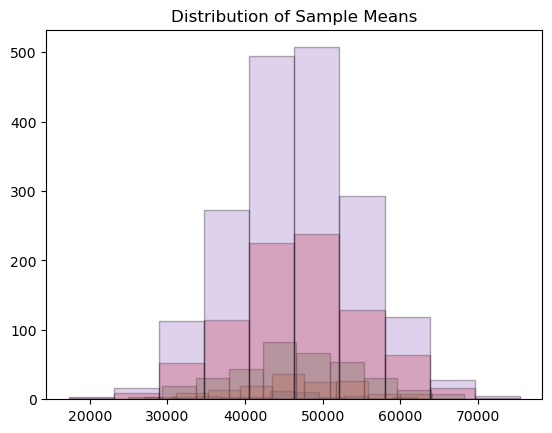

In [30]:
import random
sample_means = []
sample_stds = []
for n in [ 50, 100, 200, 500, 1000 ]:
    for i in range(n):
        sample = random.sample(salaries, k=30) 
        sample_mean = np.mean(sample)        
        sample_means.append(sample_mean)
        sample_std = np.std(sample)
        sample_stds.append(sample_std)
    plt.hist(sample_means, edgecolor = 'black', alpha = 0.3)
    plt.title('Distribution of Sample Means');
    sample_mean = np.mean(sample_means)
    sample_std = np.mean(sample_stds)
    print(n)
    print("mean of sample means ", sample_mean)
    print("std of sample means ", sample_std)
    

In [31]:
normalized_data = (salaries - data_mean) / data_std

In [32]:
normalized_data 

array([ 0.87248912,  0.87248912,  0.87248912, ..., -1.03685172,
       -1.03685172, -1.03685172], shape=(590210,))

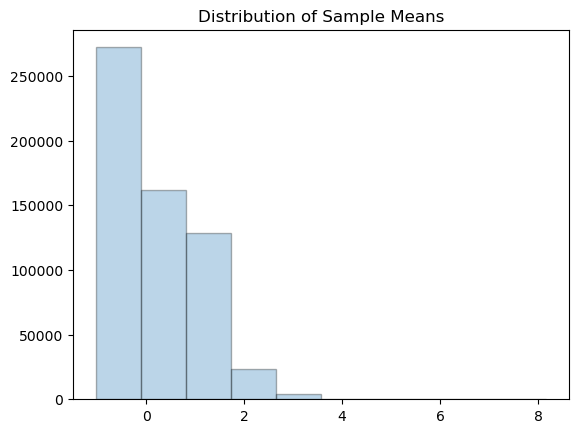

In [33]:
plt.hist(normalized_data, edgecolor = 'black', alpha = 0.3)
plt.title('Distribution of Sample Means');

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import uniform, norm

46191.808121999995
8361.853046013024


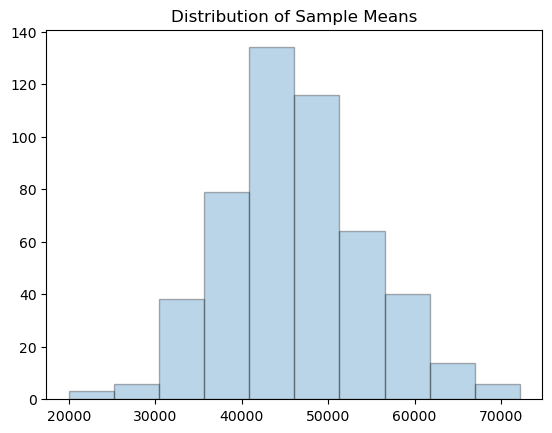

In [35]:
gauss_dist = norm(loc = 5, scale = 10)
sample_means_gauss = []
for i in range(500):
    sample = random.sample(salaries, k=30) 
    sample_mean = np.mean(sample)
    sample_means_gauss.append(sample_mean)

gauss_mean = np.mean(sample_means_gauss)
gauss_standard_deviation = np.std(sample_means_gauss)

plt.hist(sample_means_gauss, edgecolor = 'black', alpha = 0.3)
plt.title('Distribution of Sample Means');
# Answer check

print(gauss_mean)
print(gauss_standard_deviation)

46632.948620079995
1432.5675285771988

46658.23878022
1439.6979860287308

46692.624298840004
1441.0543234685938

46700.92599148
1439.517082206242

46687.559232643995
1443.3780043266981



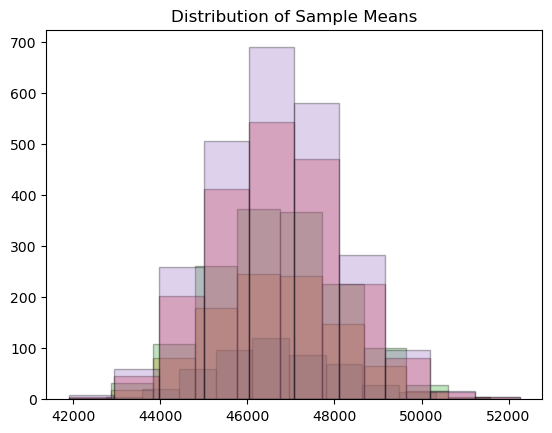

In [36]:
gauss_dist = salaries
sample_means_gauss = []
for n in range(5):
    for i in range(500):
        sample = random.sample(salaries, k=1000) 
        sample_mean = np.mean(sample)
        sample_means_gauss.append(sample_mean)
    
    gauss_mean = np.mean(sample_means_gauss)
    gauss_standard_deviation = np.std(sample_means_gauss)
    
    print(gauss_mean)
    print(gauss_standard_deviation)
    print()
    plt.hist(sample_means_gauss, edgecolor = 'black', alpha = 0.3)
    plt.title('Distribution of Sample Means');
# Answer check


In [37]:
import random

random.seed(42) 

for sample_size in [1,5,10, 20, 30, 50, 100, 500, 1000]:
    sample_means = []
    sample_stds = []
    for i in range(500):
        sample = random.sample(salaries, k=sample_size) 
        
        sample_mean = np.mean(sample)        
        sample_means.append(sample_mean)
        
        sample_std = np.std(sample)
        sample_stds.append(sample_std)
    
    sample_mean = np.mean(sample_means)
    sample_std = np.mean(sample_stds)
    print(sample_size)
    print("mean ", sample_mean)
    print("std ", sample_std)
    print()

1
mean  43797.87492
std  0.0

5
mean  45034.499188
std  38361.80844083774

10
mean  47215.301922
std  42033.4776804672

20
mean  46938.784037
std  43272.841690272704

30
mean  46897.431423999995
std  44225.65761103565

50
mean  46774.419883200004
std  44508.01160792785

100
mean  46782.5475418
std  44640.353447979025

500
mean  46592.587607
std  44967.52078919993

1000
mean  46711.77278204
std  44968.40660746108



In [38]:
type(salaries)

list

In [39]:
np.mean(salaries)

np.float64(46719.46439313126)

In [40]:
len (salaries)

590210

In [41]:
np.std(salaries)

np.float64(45026.96354833033)

In [42]:
sample = random.sample(salaries, k=5) 
sample

[np.float64(44930.0),
 np.float64(15.0),
 np.float64(33.18),
 np.float64(86347.0),
 np.float64(59.29)]

In [43]:
100 - (46121/46719 * 100)

1.2799931505383313